In [27]:
# Carga de datos
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from pickle import dump

# Cargar el dataset
url = "https://raw.githubusercontent.com/4GeeksAcademy/k-nearest-neighbors-project-tutorial/refs/heads/main/winequality-red.csv"
df = pd.read_csv(url, sep =";")

print("Shape del dataset:", df.shape)
df.head()

Shape del dataset: (1599, 12)


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


In [28]:
# Explorar estructura
print("Tipos de datos:")
print(df.dtypes)

print("\nValores nulos:")
print(df.isnull().sum())

def quality_to_label(q):
    if q <= 4:
        return 0  # low
    elif q <= 6:
        return 1  # medium
    else:
        return 2  # high

df['label'] = df['quality'].apply(quality_to_label)

print("\nDistribución de la variable objetivo (label):")
print(df['label'].value_counts())
print("\n0 = Baja calidad | 1 = Calidad media | 2 = Alta calidad")

Tipos de datos:
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object

Valores nulos:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Distribución de la variable objetivo (label):
label
1    1319
2     217
0      63
Name: count, dtype: int64

0 = Baja calidad | 1 = Calidad media | 2 = Alta calidad


In [29]:
# Estadísticas descriptivas
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,label
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023,1.096310
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569,0.407354
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000,0.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000,1.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000,1.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000,1.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000,2.000000


In [30]:
# Separar variables independientes (X) y objetivo (y)
X = df.drop(["label", "quality"], axis=1)
y = df["label"]

print("Variables predictoras:", list(X.columns))
print("Variable objetivo: label")

Variables predictoras: ['fixed acidity', 'volatile acidity', 'citric acid', 'residual sugar', 'chlorides', 'free sulfur dioxide', 'total sulfur dioxide', 'density', 'pH', 'sulphates', 'alcohol']
Variable objetivo: label


In [31]:
# Dividir en conjunto de entrenamiento y prueba (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Tamaño entrenamiento: {X_train.shape}")
print(f"Tamaño prueba: {X_test.shape}")

Tamaño entrenamiento: (1279, 11)
Tamaño prueba: (320, 11)


In [32]:
# Escalar los datos 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos escalados correctamente.")
print("Media post-escalado (train):", X_train_scaled.mean().round(4))
print("Std post-escalado (train):", X_train_scaled.std().round(4))

Datos escalados correctamente.
Media post-escalado (train): -0.0
Std post-escalado (train): 1.0


In [33]:
# Entrenar el modelo KNN con k inicial = 5 (valor por defecto)
model = KNeighborsClassifier(n_neighbors=5)
model.fit(X_train_scaled, y_train)

print("Modelo entrenado exitosamente.")
print(model)

Modelo entrenado exitosamente.
KNeighborsClassifier()


In [34]:
# Predicciones sobre el conjunto de prueba
y_pred = model.predict(X_test_scaled)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy (k=5): {acc:.4f} ({acc*100:.2f}%)")

Accuracy (k=5): 0.8187 (81.88%)


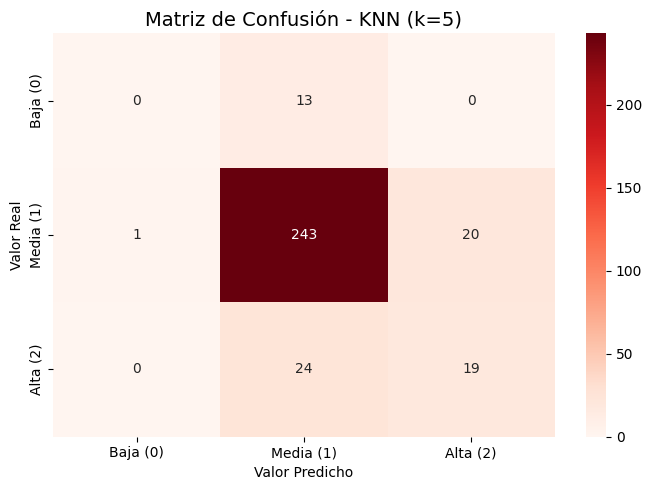

In [35]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)

fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Reds',
    xticklabels=['Baja (0)', 'Media (1)', 'Alta (2)'],
    yticklabels=['Baja (0)', 'Media (1)', 'Alta (2)'],
    ax=ax
)
ax.set_title('Matriz de Confusión - KNN (k=5)', fontsize=14)
ax.set_ylabel('Valor Real')
ax.set_xlabel('Valor Predicho')
plt.tight_layout()
plt.show()

In [36]:
# Reporte de clasificación completo
print("Classification Report:")
print(classification_report(
    y_test, y_pred,
    target_names=['Baja calidad (0)', 'Calidad media (1)', 'Alta calidad (2)'],
    zero_division=0
))

Classification Report:
                   precision    recall  f1-score   support

 Baja calidad (0)       0.00      0.00      0.00        13
Calidad media (1)       0.87      0.92      0.89       264
 Alta calidad (2)       0.49      0.44      0.46        43

         accuracy                           0.82       320
        macro avg       0.45      0.45      0.45       320
     weighted avg       0.78      0.82      0.80       320



In [37]:
# Probar diferentes valores de k de 1 a 20
k_values = list(range(1, 21))
train_accuracies = []
test_accuracies = []

for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    
    train_accuracies.append(accuracy_score(y_train, knn.predict(X_train_scaled)))
    test_accuracies.append(accuracy_score(y_test, knn.predict(X_test_scaled)))

# Encontrar el mejor k
best_k = k_values[test_accuracies.index(max(test_accuracies))]
best_acc = max(test_accuracies)
print(f"Mejor valor de k: {best_k} con accuracy = {best_acc:.4f} ({best_acc*100:.2f}%)")

Mejor valor de k: 11 con accuracy = 0.8594 (85.94%)


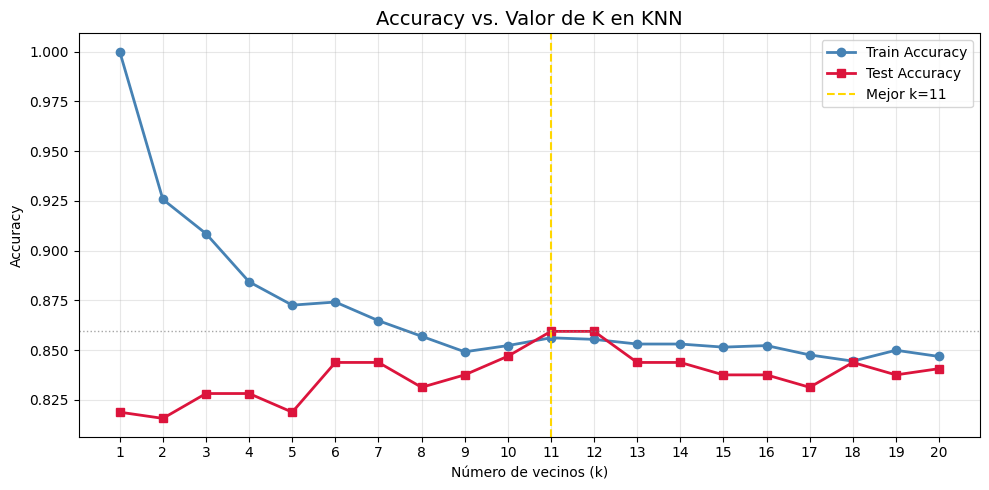


Nota: k pequeño → mayor riesgo de overfitting (train >> test)
      k grande → modelo más generalizable pero puede perder detalle


In [38]:
# Gráfica de accuracy vs k
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(k_values, train_accuracies, marker='o', label='Train Accuracy', color='steelblue', linewidth=2)
ax.plot(k_values, test_accuracies, marker='s', label='Test Accuracy', color='crimson', linewidth=2)
ax.axvline(x=best_k, color='gold', linestyle='--', linewidth=1.5, label=f'Mejor k={best_k}')
ax.axhline(y=best_acc, color='gray', linestyle=':', linewidth=1, alpha=0.7)

ax.set_title('Accuracy vs. Valor de K en KNN', fontsize=14)
ax.set_xlabel('Número de vecinos (k)')
ax.set_ylabel('Accuracy')
ax.set_xticks(k_values)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nNota: k pequeño → mayor riesgo de overfitting (train >> test)")
print(f"      k grande → modelo más generalizable pero puede perder detalle")

In [39]:
# Entrenar el modelo final con el mejor k encontrado
best_model = KNeighborsClassifier(n_neighbors=best_k)
best_model.fit(X_train_scaled, y_train)
y_pred_best = best_model.predict(X_test_scaled)

print(f"Modelo final con k={best_k}")
print(f"Accuracy final: {accuracy_score(y_test, y_pred_best):.4f}")
print("\nClassification Report final:")
print(classification_report(
    y_test, y_pred_best,
    target_names=['Baja calidad (0)', 'Calidad media (1)', 'Alta calidad (2)'],
    zero_division=0
))

Modelo final con k=11
Accuracy final: 0.8594

Classification Report final:
                   precision    recall  f1-score   support

 Baja calidad (0)       0.00      0.00      0.00        13
Calidad media (1)       0.89      0.95      0.92       264
 Alta calidad (2)       0.64      0.58      0.61        43

         accuracy                           0.86       320
        macro avg       0.51      0.51      0.51       320
     weighted avg       0.82      0.86      0.84       320



In [40]:
def predict_wine_quality(features):
    """
    Predice la calidad de un vino tinto dado sus características químicas.

    Parámetros:
    -----------
    features : list de 11 valores en este orden:
        [fixed acidity, volatile acidity, citric acid, residual sugar,
         chlorides, free sulfur dioxide, total sulfur dioxide,
         density, pH, sulphates, alcohol]

    Retorna:
    --------
    str : Mensaje con la predicción de calidad
    """
    labels = {
        0: "baja calidad ",
        1: "calidad media ",
        2: "alta calidad "
    }

    # Convertir a DataFrame con los mismos nombres de columna del entrenamiento
    input_array = pd.DataFrame([features], columns=X.columns)
    input_scaled = scaler.transform(input_array)

    # Predecir
    prediction = best_model.predict(input_scaled)[0]

    return f"Este vino probablemente sea de {labels[prediction]}"


# Pruebas
resultado = predict_wine_quality([7.4, 0.7, 0.0, 1.9, 0.076, 11.0, 34.0, 0.9978, 3.51, 0.56, 9.4])
print(resultado)
print(predict_wine_quality([8.1, 0.28, 0.40, 6.9, 0.050, 30.0, 97.0, 0.9951, 3.26, 0.44, 10.1]))
print(predict_wine_quality([9.5, 0.30, 0.45, 2.0, 0.065, 10.0, 30.0, 0.9950, 3.20, 0.75, 12.5]))

Este vino probablemente sea de calidad media 
Este vino probablemente sea de calidad media 
Este vino probablemente sea de alta calidad 


In [41]:
# Guardar modelo y scaler
dump(best_model, open(f"../models/knn_wine_classifier_k{best_k}.sav", "wb"))
dump(scaler, open("../models/scaler_wine.sav", "wb"))

print(f"Modelo guardado como: knn_wine_classifier_k{best_k}.sav")
print("Scaler guardado como: scaler_wine.sav")


Modelo guardado como: knn_wine_classifier_k11.sav
Scaler guardado como: scaler_wine.sav
